# Connect Four CNN — Training Notebook

This notebook:
1. Generates a dataset of Connect Four games using `DatasetGenerator` and saves board images via `DatasetSaver`'s RGB encoding.
2. Loads the images into a PyTorch `Dataset` with an 80/20 train/val split.
3. Trains the `ConnectFourCNN` from `model/model.py` for 20 epochs with BCELoss and Adam.
4. Plots training/validation loss and accuracy curves.
5. Displays example board images with predicted probabilities.
6. Saves trained model weights to `experiment/model.pth`.

**Label convention:**
- `1` — board state occurs on the **winner's turn** (the winning player is about to move)
- `0` — board state occurs on the **loser's turn**

**Image encoding (matches `DatasetSaver`):**
- Red channel: winner's chip positions
- Green channel: loser's chip positions
- Black (all zeros): empty cells

## 0. Imports & Configuration

In [4]:
import sys
import os

# Add the repository root to sys.path so we can import src/ and model/
sys.path.insert(0, '..')

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt

from src.DatasetGenerator import DatasetGenerator
from src.DatasetSaver import DatasetSaver
from src.FourInLine import BLUE_CHIP
from model.model import ConnectFourCNN

In [5]:
# ----- Hyper-parameters & paths -----
NUM_GAMES    = 1000   # number of games to simulate
WIDTH        = 7
HEIGHT       = 6
DATA_DIR     = 'data'
BATCH_SIZE   = 64
NUM_EPOCHS   = 20
LEARNING_RATE = 1e-3
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Generate Dataset

For each game we:
- Play a full non-tie game with `DatasetGenerator.playRandomGame()`.
- Retrieve the complete board history.
- Use `DatasetSaver.convertToRGBArray()` to encode each board (red = winner chips, green = loser chips).
- Save winner-turn boards under `data/win/` (label 1) and loser-turn boards under `data/loss/` (label 0).

Winner-turn indices follow the same pattern as `DatasetSaver.getWinnerBoardHistory()`: even indices when BLUE wins, odd when RED wins.

In [6]:
os.makedirs(os.path.join(DATA_DIR, 'win'),  exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'loss'), exist_ok=True)

total_win  = 0
total_loss = 0

for game_idx in range(NUM_GAMES):
    generator = DatasetGenerator(WIDTH, HEIGHT)
    # DatasetSaver is used for its RGB encoding logic (convertToRGBArray)
    saver = DatasetSaver(generator, DATA_DIR)

    generator.playRandomGame()          # guaranteed non-tie result
    winner     = generator.game.getWinner()
    all_boards = generator.getBoardHistory()

    # Match the indexing used by DatasetGenerator.getWinnerBoardHistory()
    history_start = 0 if winner == BLUE_CHIP else 1
    winner_turn_indices = set(range(history_start, len(all_boards), 2))

    for b_idx, board in enumerate(all_boards):
        # Encode using DatasetSaver's convention: red=winner, green=loser
        rgb = saver.convertToRGBArray(board).astype(np.uint8)
        img = Image.fromarray(rgb)

        if b_idx in winner_turn_indices:
            subfolder = 'win'
            total_win += 1
        else:
            subfolder = 'loss'
            total_loss += 1

        filename = f'game_{game_idx:04d}_board_{b_idx:04d}.png'
        img.save(os.path.join(DATA_DIR, subfolder, filename))

    if (game_idx + 1) % 200 == 0:
        print(f'  Games completed: {game_idx + 1}/{NUM_GAMES}')

print(f'\nDataset saved to {DATA_DIR}/')
print(f'  Win boards  (label 1): {total_win}')
print(f'  Loss boards (label 0): {total_loss}')
print(f'  Total:                 {total_win + total_loss}')

  Games completed: 200/1000
  Games completed: 400/1000
  Games completed: 600/1000
  Games completed: 800/1000
  Games completed: 1000/1000

Dataset saved to data/
  Win boards  (label 1): 10641
  Loss boards (label 0): 11063
  Total:                 21704


## 2. Load Dataset & Create DataLoaders

In [7]:
class ConnectFourDataset(Dataset):
    """Loads Connect Four board PNG images and their binary labels."""

    def __init__(self, image_paths: list, labels: list):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        # Load PNG, convert to (3, H, W) float tensor in [0, 1]
        img = np.array(Image.open(self.image_paths[idx]))  # (H, W, 3)
        tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        label  = torch.tensor([self.labels[idx]], dtype=torch.float32)
        return tensor, label

In [8]:
win_dir  = os.path.join(DATA_DIR, 'win')
loss_dir = os.path.join(DATA_DIR, 'loss')

win_paths  = sorted([os.path.join(win_dir,  f) for f in os.listdir(win_dir)  if f.endswith('.png')])
loss_paths = sorted([os.path.join(loss_dir, f) for f in os.listdir(loss_dir) if f.endswith('.png')])

all_paths  = win_paths + loss_paths
all_labels = [1] * len(win_paths) + [0] * len(loss_paths)

dataset = ConnectFourDataset(all_paths, all_labels)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Total samples : {len(dataset)}')
print(f'  Train       : {len(train_dataset)}')
print(f'  Validation  : {len(val_dataset)}')

Total samples : 21704
  Train       : 17363
  Validation  : 4341


## 3. Train the Model

In [9]:
model     = ConnectFourCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

ConnectFourCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=64, out_features=1, bias=True)
    (6): Sigmoid()
  )
)

Trainable para

In [10]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):

    # ------ Training phase ------
    model.train()
    running_loss = 0.0
    correct      = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(X)
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        correct      += ((preds > 0.5).float() == y).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc  = correct      / len(train_dataset)

    # ------ Validation phase ------
    model.eval()
    running_loss = 0.0
    correct      = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss  = criterion(preds, y)
            running_loss += loss.item() * X.size(0)
            correct      += ((preds > 0.5).float() == y).sum().item()

    epoch_val_loss = running_loss / len(val_dataset)
    epoch_val_acc  = correct      / len(val_dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'train_loss={epoch_train_loss:.4f}  train_acc={epoch_train_acc:.4f} | '
          f'val_loss={epoch_val_loss:.4f}  val_acc={epoch_val_acc:.4f}')

Epoch 01/20 | train_loss=0.5185  train_acc=0.7289 | val_loss=0.4312  val_acc=0.7784
Epoch 02/20 | train_loss=0.4011  train_acc=0.8026 | val_loss=0.5970  val_acc=0.7015
Epoch 03/20 | train_loss=0.3515  train_acc=0.8250 | val_loss=0.3791  val_acc=0.8067
Epoch 04/20 | train_loss=0.3247  train_acc=0.8380 | val_loss=0.3459  val_acc=0.8194
Epoch 05/20 | train_loss=0.2984  train_acc=0.8486 | val_loss=0.3715  val_acc=0.8173
Epoch 06/20 | train_loss=0.2770  train_acc=0.8630 | val_loss=0.2810  val_acc=0.8542
Epoch 07/20 | train_loss=0.2611  train_acc=0.8692 | val_loss=0.2866  val_acc=0.8436
Epoch 08/20 | train_loss=0.2488  train_acc=0.8715 | val_loss=1.3509  val_acc=0.6669
Epoch 09/20 | train_loss=0.2375  train_acc=0.8795 | val_loss=0.4055  val_acc=0.8063
Epoch 10/20 | train_loss=0.2292  train_acc=0.8835 | val_loss=0.3655  val_acc=0.8309
Epoch 11/20 | train_loss=0.2226  train_acc=0.8888 | val_loss=0.3148  val_acc=0.8507
Epoch 12/20 | train_loss=0.2096  train_acc=0.8924 | val_loss=0.4065  val_acc

## 4. Loss & Accuracy Curves

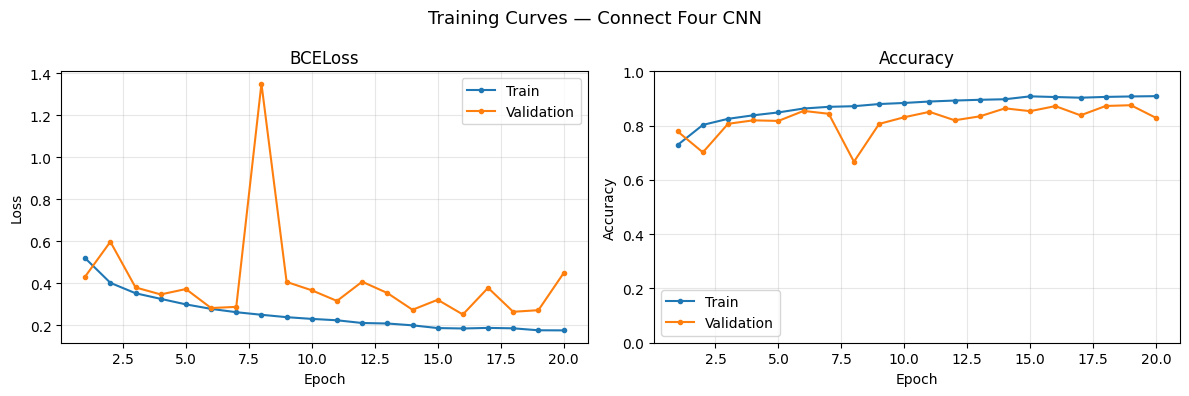

Saved training_curves.png


In [11]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, label='Train',      marker='o', markersize=3)
axes[0].plot(epochs, val_losses,   label='Validation', marker='o', markersize=3)
axes[0].set_title('BCELoss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, train_accs, label='Train',      marker='o', markersize=3)
axes[1].plot(epochs, val_accs,   label='Validation', marker='o', markersize=3)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves — Connect Four CNN', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 5. Example Predictions

Eight randomly selected validation boards with their true label and predicted probability.
A predicted probability > 0.5 means the model thinks it is the winner's turn.

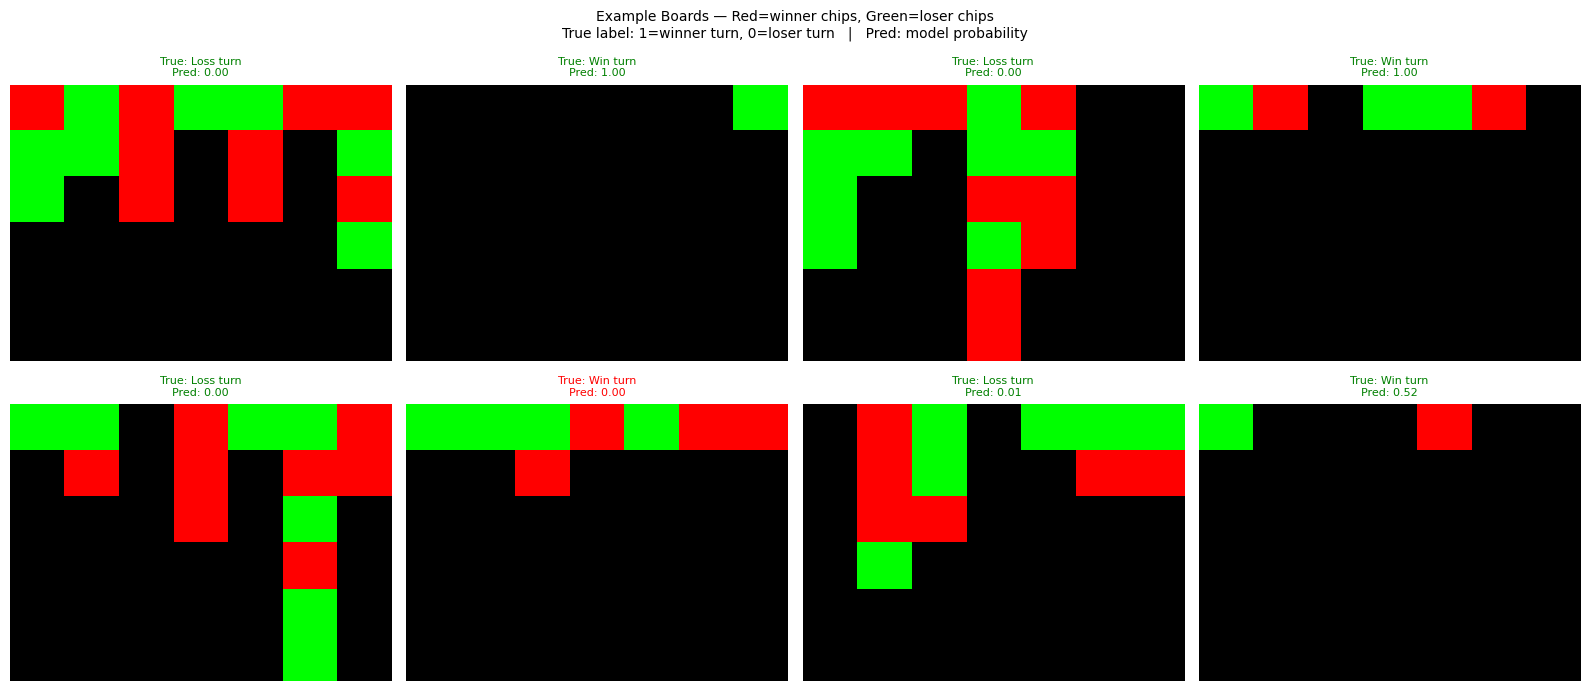

Saved example_predictions.png


In [12]:
model.eval()

rng     = np.random.default_rng(SEED)
n_show  = min(8, len(val_dataset))
indices = rng.choice(len(val_dataset), size=n_show, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(
    'Example Boards — Red=winner chips, Green=loser chips\n'
    'True label: 1=winner turn, 0=loser turn   |   Pred: model probability',
    fontsize=10
)

for i, idx in enumerate(indices):
    img_tensor, label = val_dataset[idx]

    with torch.no_grad():
        prob = model(img_tensor.unsqueeze(0).to(device)).item()

    ax  = axes[i // 4][i % 4]
    # CHW -> HWC for matplotlib
    display = img_tensor.permute(1, 2, 0).numpy()
    ax.imshow(display, interpolation='nearest', aspect='auto')
    true_str = 'Win turn' if int(label.item()) == 1 else 'Loss turn'
    pred_str = f'{prob:.2f}'
    correct  = (prob > 0.5) == (int(label.item()) == 1)
    color    = 'green' if correct else 'red'
    ax.set_title(f'True: {true_str}\nPred: {pred_str}', fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('example_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved example_predictions.png')

## 6. Save Model Weights

In [13]:
torch.save(model.state_dict(), 'model.pth')
print('Model weights saved to experiment/model.pth')
print(f'Final val_loss={val_losses[-1]:.4f}  val_acc={val_accs[-1]:.4f}')

Model weights saved to experiment/model.pth
Final val_loss=0.4473  val_acc=0.8284
